# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [16]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [17]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [18]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [19]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [20]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

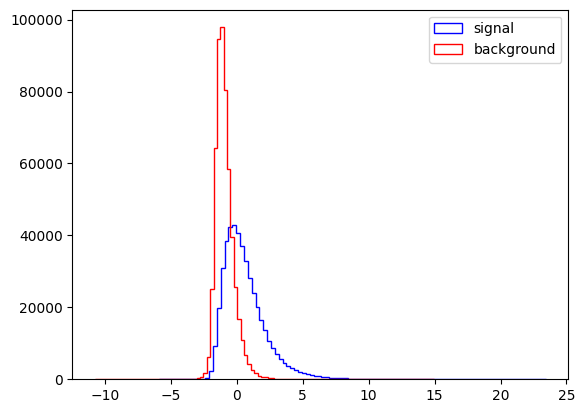

In [21]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

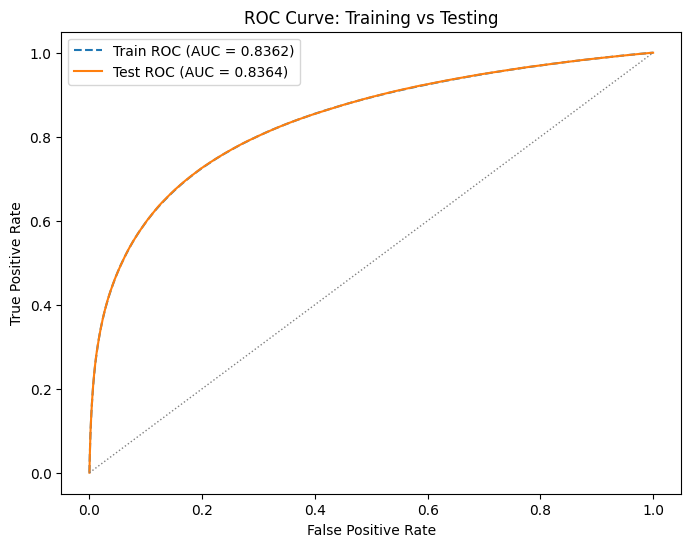

In [22]:
from sklearn.metrics import roc_curve, auc

# Gets the raw model scores which is how far the distance is from the decision boundary for both sets
# decision_function gives the distance to the separating hyperplane
scores_train = Fisher.decision_function(X_Train)
scores_test = Fisher.decision_function(X_Test)

# Calculates False Positive Rate and True Positive Rate for the training sets
fpr_train, tpr_train, _ = roc_curve(y_Train, scores_train)
auc_train = auc(fpr_train, tpr_train)
# Does the same for the testing set to compare performance
fpr_test, tpr_test, _ = roc_curve(y_Test, scores_test)
auc_test = auc(fpr_test, tpr_test)

# 3. Plotting both curves, if they overlap closely, the model is not overfitted
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.4f})', linestyle='--')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {auc_test:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':') # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Training vs Testing')
plt.legend()
plt.show()

# If AUC_train is significantly higher than AUC_test, there is a bias (overfitting).

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

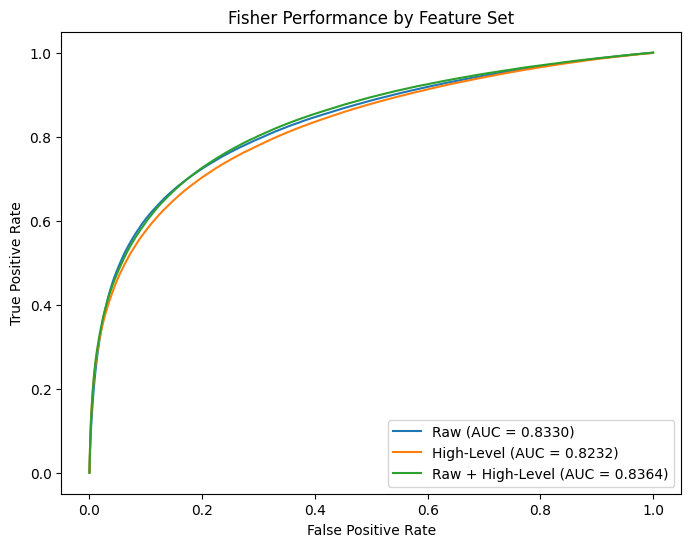

In [23]:
# Group variables into raw detector data and physics derived
raw_features = VarNames[1:9]          # l_1_pT to MET_phi
high_level_features = VarNames[9:]    # MET_rel to cos_theta_r1
all_features = VarNames[1:]

feature_sets = {
    "Raw": raw_features,
    "High-Level": high_level_features,
    "Raw + High-Level": all_features
}

plt.figure(figsize=(8, 6))
# Iterates through each set, train a new Fisher model, and plot the result
for label, cols in feature_sets.items():
    # Re-train Fisher for each specific set of columns
    lda = DA.LinearDiscriminantAnalysis()
    lda.fit(X_Train[cols], y_Train)
    
    # Evaluate on test set
    fpr, tpr, _ = roc_curve(y_Test, lda.decision_function(X_Test[cols]))
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.4f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fisher Performance by Feature Set')
plt.legend()
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

Training Logistic Regression...
Training Naive Bayes...
Training Random Forest (Limited)...


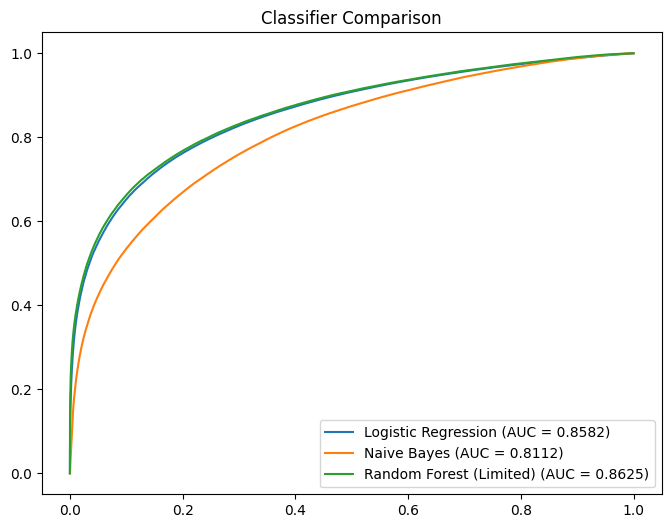

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
# A generic function to handle different classifier types
def compare_classifiers(clf, name, X_train, y_train, X_test, y_test):
    """
    Fits a classifier and returns the FPR and TPR for plotting.
    """
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    
    # Some classifiers use predict_proba, others use decision_function
    if hasattr(clf, "decision_function"):
        scores = clf.decision_function(X_test)     # Check if the model uses decision_function like LDA or predict_proba like Naive Bayes
    else:
        scores = clf.predict_proba(X_test)[:, 1]
        
    fpr, tpr, thresholds = roc_curve(y_test, scores)
    return fpr, tpr, auc(fpr, tpr), scores

# Initialize models
models = [
    (LogisticRegression(max_iter=1000), "Logistic Regression"),
    (GaussianNB(), "Naive Bayes"),
    # Using a small subset or limited depth for RF if 4M rows is too slow
    (RandomForestClassifier(n_estimators=10, max_depth=10, n_jobs=-1), "Random Forest (Limited)")
]

plt.figure(figsize=(8, 6))
results_data = {} # To store scores for Part C

for clf, name in models:
    fpr, tpr, score_auc, scores = compare_classifiers(clf, name, X_Train, y_Train, X_Test, y_Test)
    results_data[name] = scores
    plt.plot(fpr, tpr, label=f'{name} (AUC = {score_auc:.4f})')

plt.legend()
plt.title("Classifier Comparison")
plt.show()

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Generates the ROC curve data
# thresholds contains the potential decision boundaries the model could use
def get_metrics(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    
    # Calculate Significance for every threshold
    # Assuming Ns and Nb are total counts in the test set
    # convert rates TPR/FPR back into event counts (Ns/Nb)
    total_s = np.sum(y_true == 1)
    total_b = np.sum(y_true == 0)

    # Calculate the number of Signal (ns) and Background (nb) events at every threshold
    # ns = True Positive Rate * Total actual signal
    # nb = False Positive Rate * Total actual background
    ns = tpr * total_s
    nb = fpr * total_b

    # Calculate the Discovery Significance for every threshold, Significance = S / sqrt(S + B)
    # Adds 1e-10 to the denominator to prevent errors
    significance = ns / np.sqrt(ns + nb + 1e-10) # 1e-10 to avoid div by zero
    max_sig_idx = np.argmax(significance)
    best_threshold = thresholds[max_sig_idx]
    
    # Get binary predictions based on the best threshold for significance
    y_pred = (scores >= best_threshold).astype(int)
    
    return {
        "AUC": auc(fpr, tpr),
        "Max Sig": np.max(significance),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred)
    }

# Assuming "Logistic Regression" was our best from 4b
final_metrics = get_metrics(y_Test, results_data["Logistic Regression"])

# Create table
table = [["Metric", "Value"]]
for key, val in final_metrics.items():
    table.append([key, f"{val:.4f}"])

display(HTML(tabulate.tabulate(table, tablefmt='html')))

Metric,Value
AUC,0.8582
Max Sig,516.6786
Precision,0.7401
Recall,0.7871
F1,0.7629
Accuracy,0.7758


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

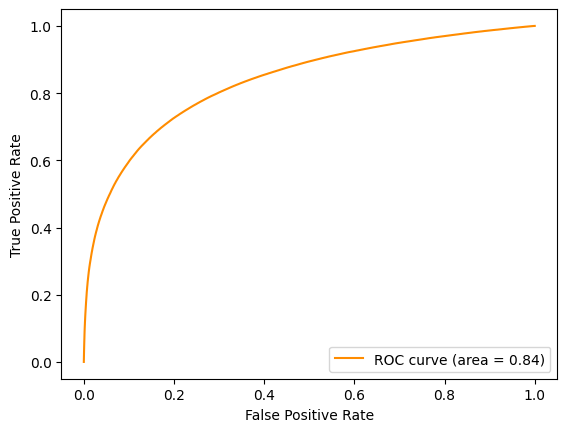

In [26]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
import numpy as np

def evaluate_model_performance(y_true, scores):

    # 1. Compute ROC and AUC, cuts the data. AUC = 1.0 is perfect; 0.5 is random guessing.
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    
    # Calculates Significance for every threshold to find the maximum
    # N_S = True Positive Rate * Total Signal Events
    # N_B = False Positive Rate * Total Background Events
    # event counts (Ns and Nb) based on test sample size.
    total_signal = np.sum(y_true == 1)
    total_background = np.sum(y_true == 0)
    
    n_s = tpr * total_signal
    n_b = fpr * total_background
    
    # Avoid division by zero with a small epsilon
    # Identifies the highest significance achieved and its index
    significance = n_s / np.sqrt(n_s + n_b + 1e-10)
    max_sig_idx = np.argmax(significance)
    max_significance = significance[max_sig_idx]  # uses this threshold to turn continuous scores into binary 1s and 0s.
     
    # Applies the threshold that maximizes significance for other metrics
    # Finds the specific model score that produced that max significance.
    best_threshold = thresholds[max_sig_idx]
    y_pred = (scores >= best_threshold).astype(int)
    
    # Gathers metrics
    results = {
        "AUC": roc_auc,
        "Max Significance": max_significance,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "TPR (at Max Sig)": tpr[max_sig_idx],
        "FPR (at Max Sig)": fpr[max_sig_idx]
    }
    
    return results


# takes the raw output scores from trained Fisher discriminant
test_scores = Fisher.decision_function(X_Test)
metrics = evaluate_model_performance(y_Test, test_scores)

# Create a table for display
table_data = [["Metric", "Value"]]
for key, value in metrics.items():
    table_data.append([key, f"{value:.4f}"])

display(HTML(tabulate.tabulate(table_data, tablefmt='html')))

Metric,Value
AUC,0.8364
Max Significance,504.8581
Accuracy,0.7508
Precision,0.7022
Recall,0.7921
F1 Score,0.7445
TPR (at Max Sig),0.7921
FPR (at Max Sig),0.2841


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def calculate_max_significance(y_true, scores):
# Generate the ROC curve data: False Positive Rate, True Positive Rate, and the thresholds
# These thresholds represent every possible 'ut the model could use to separate signal from background.
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    
    # Calculate counts based on test sample size
    total_s = np.sum(y_true == 1)
    total_b = np.sum(y_true == 0)
    
    # Calculate N_s and N_b for every possible threshold
    ns = tpr * total_s
    nb = fpr * total_b
    
    # Significance formula: S / sqrt(S + B)
    # Adding a tiny epsilon to avoid division by zero
    significance = ns / np.sqrt(ns + nb + 1e-10)
    
    # Find the threshold that gives the highest significance
    max_idx = np.argmax(significance)
    best_threshold = thresholds[max_idx]
    max_sig = significance[max_idx]
    
    # Generate binary predictions (0 or 1) using this optimal threshold
    # Scores above the best_threshold are labeled as signal (1).
    y_pred = (scores >= best_threshold).astype(int)
    
    return {
        "AUC": auc(fpr, tpr),
        "Max Significance": max_sig,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

# train a model using Logistic Regression
# Ensure X_Train contains the correct feature set
best_model = LogisticRegression(max_iter=1000).fit(X_Train, y_Train)
test_scores = best_model.decision_function(X_Test)
# Pass the true labels and model scores into significance calculator
results = calculate_max_significance(y_Test, test_scores)

# Create the summary table
table = [["Metric", "Value"]]
for key, val in results.items():
    table.append([key, f"{val:.4f}"])

display(HTML(tabulate.tabulate(table, tablefmt='html')))

Metric,Value
AUC,0.8582
Max Significance,516.6786
Accuracy,0.7758
Precision,0.7401
Recall,0.7871
F1 Score,0.7629
